# Deep Probabilistic Imaging (DPI) for EHT Black Hole UQ
### Posterior Estimation with Normalizing Flows

---

This notebook demonstrates posterior sampling and uncertainty quantification
for EHT black hole imaging using the Deep Probabilistic Imaging (DPI) method
(Sun & Bouman 2020, arXiv:2010.14462).

**Contents**
1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
2. [Load Pretrained Model](#2.-Load-Pretrained-Model)
3. [Generate Posterior Samples](#3.-Generate-Posterior-Samples)
4. [Posterior Mean & Uncertainty Maps](#4.-Posterior-Mean-&-Uncertainty-Maps)
5. [Multi-Modal Posterior (t-SNE + K-Means)](#5.-Multi-Modal-Posterior)
6. [Forward Model Verification](#6.-Forward-Model-Verification)
7. [Training from Scratch (Optional)](#7.-Training-from-Scratch)
8. [Evaluation & Metrics](#8.-Evaluation-&-Metrics)

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

TASK_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if TASK_ROOT not in sys.path:
    sys.path.insert(0, TASK_ROOT)

from src.preprocessing import prepare_data, load_ground_truth, load_metadata
from src.solvers import RealNVP, Img_logscale, DPISolver
from src.physics_model import NUFFTForwardModel
from src.visualization import (
    plot_image, plot_posterior_summary, plot_posterior_samples,
    plot_loss_curves, compute_metrics, compute_uq_metrics, print_metrics_table,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
REF_DIR = os.path.join(TASK_ROOT, 'evaluation', 'reference_outputs')
print(f'Setup complete. Device: {device}')

Welcome to eht-imaging! v 1.2.4 

Setup complete. Device: cuda


---
## 1. Setup & Data Loading

Load the EHT observation (UVFITS), extract closure quantities, and build the
prior image for MEM regularization.

In [2]:
(obs_data, closure_indices, nufft_params,
 prior_image, flux_const, metadata) = prepare_data(
    os.path.join(TASK_ROOT, 'data'))

npix = metadata['npix']
fov_uas = metadata['fov_uas']
pixel_size_uas = fov_uas / npix

ground_truth = load_ground_truth(
    os.path.join(TASK_ROOT, 'data'))

print(f'Image size       : {npix} x {npix}')
print(f'FOV              : {fov_uas} uas')
print(f'Visibilities     : {len(obs_data["vis"])}')
print(f'Closure phases   : {len(closure_indices["cphase_data"]["cphase"])}')
print(f'Closure amps     : {len(closure_indices["camp_data"]["camp"])}')
print(f'Estimated flux   : {flux_const:.4f} Jy')

Loading uvfits:  /home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_UQ/data/obs.uvfits
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
U-V flagged 115/938 visibilities
U-V flagged 823/938 visibilities
Updated self.cphase: no averaging
updated self.cphase: avg_time 0.000000 s

updated self.camp: no averaging
updated self.camp: avg_time 0.000000 s

updated self.lcamp: no averaging
updated self.logcamp: avg_time 0.000000 s

Loading fits image:  /home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_UQ/data/gt.fits
Image size       : 32 x 32
FOV              : 160.0 uas
Visibilities     : 938
Closure phases   : 465
Closure amps     : 485
Estimated flux   : 2.0445 Jy


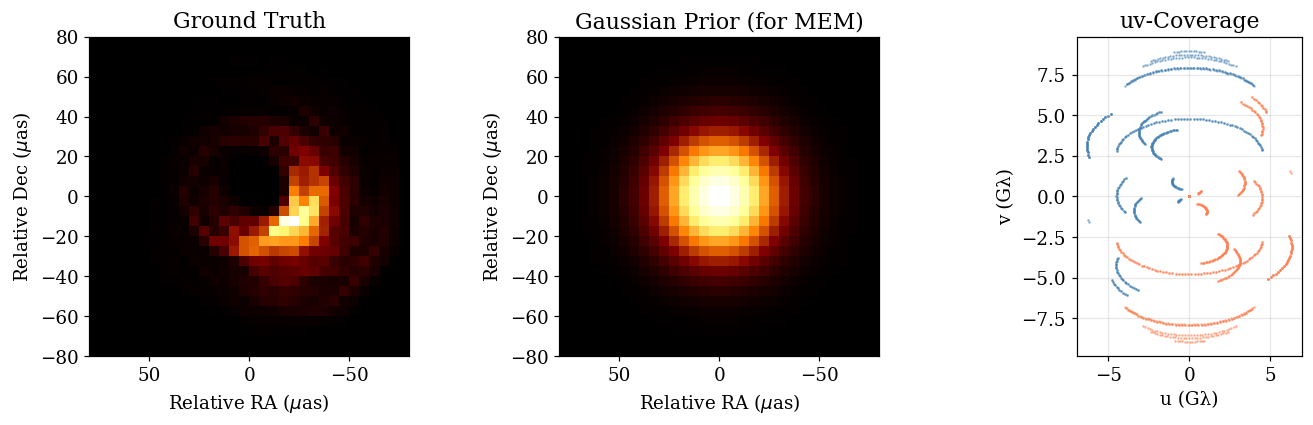

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

plot_image(ground_truth, ax=axes[0], title='Ground Truth',
           pixel_size_uas=pixel_size_uas)
plot_image(prior_image, ax=axes[1], title='Gaussian Prior (for MEM)',
           pixel_size_uas=pixel_size_uas)

uv = obs_data['uv_coords'] / 1e9
axes[2].scatter(uv[:, 0], uv[:, 1], s=0.5, alpha=0.5, c='steelblue')
axes[2].scatter(-uv[:, 0], -uv[:, 1], s=0.5, alpha=0.5, c='coral')
axes[2].set_xlabel('u (G\u03bb)')
axes[2].set_ylabel('v (G\u03bb)')
axes[2].set_title('uv-Coverage')
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Load Pretrained Model

We load a DPI model trained for 10,000 epochs with **data weight warm-up**:
the data fidelity term starts at weight 10⁻⁴ and exponentially ramps to 1.0
over ~8000 epochs, allowing the flow to first learn a reasonable prior-driven
distribution before being constrained by the data.

In [4]:
n_flow = 16

img_generator = RealNVP(npix * npix, n_flow, affine=True).to(device)
logscale_factor = Img_logscale(
    scale=flux_const / (0.8 * npix * npix)).to(device)

model_path = os.path.join(REF_DIR, 'model_state_dict.pt')
scale_path = os.path.join(REF_DIR, 'logscale_state_dict.pt')

img_generator.load_state_dict(
    torch.load(model_path, map_location=device))
logscale_factor.load_state_dict(
    torch.load(scale_path, map_location=device))

print(f'Model loaded: {sum(p.numel() for p in img_generator.parameters()):,} parameters')
print(f'Scale factor: {torch.exp(logscale_factor.forward()).item():.6e}')

Model loaded: 6,905,920 parameters
Scale factor: 2.414143e-03


---
## 3. Generate Posterior Samples

Draw 1024 posterior samples by pushing random Gaussian vectors through the
trained normalizing flow. No MCMC needed — sampling is instant.

In [5]:
n_sample = 1024
scale_factor = torch.exp(logscale_factor.forward())

all_samples = []
batch_size = 128
img_generator.eval()

with torch.no_grad():
    for start in range(0, n_sample, batch_size):
        bs = min(batch_size, n_sample - start)
        z = torch.randn(bs, npix * npix).to(device)
        img_samp, _ = img_generator.reverse(z)
        img_samp = img_samp.reshape(-1, npix, npix)
        img = torch.nn.Softplus()(img_samp) * scale_factor
        all_samples.append(img.cpu().numpy())

samples = np.concatenate(all_samples, axis=0)
posterior_mean = np.mean(samples, axis=0)
posterior_std = np.std(samples, axis=0)

print(f'Generated {samples.shape[0]} samples of shape {samples.shape[1:]}')
print(f'Posterior mean peak : {posterior_mean.max():.6f}')
print(f'Posterior mean flux : {posterior_mean.sum():.4f}')
print(f'Mean uncertainty    : {posterior_std.mean():.6f}')

Generated 1024 samples of shape (32, 32)
Posterior mean peak : 0.016002
Posterior mean flux : 2.0436
Mean uncertainty    : 0.001069


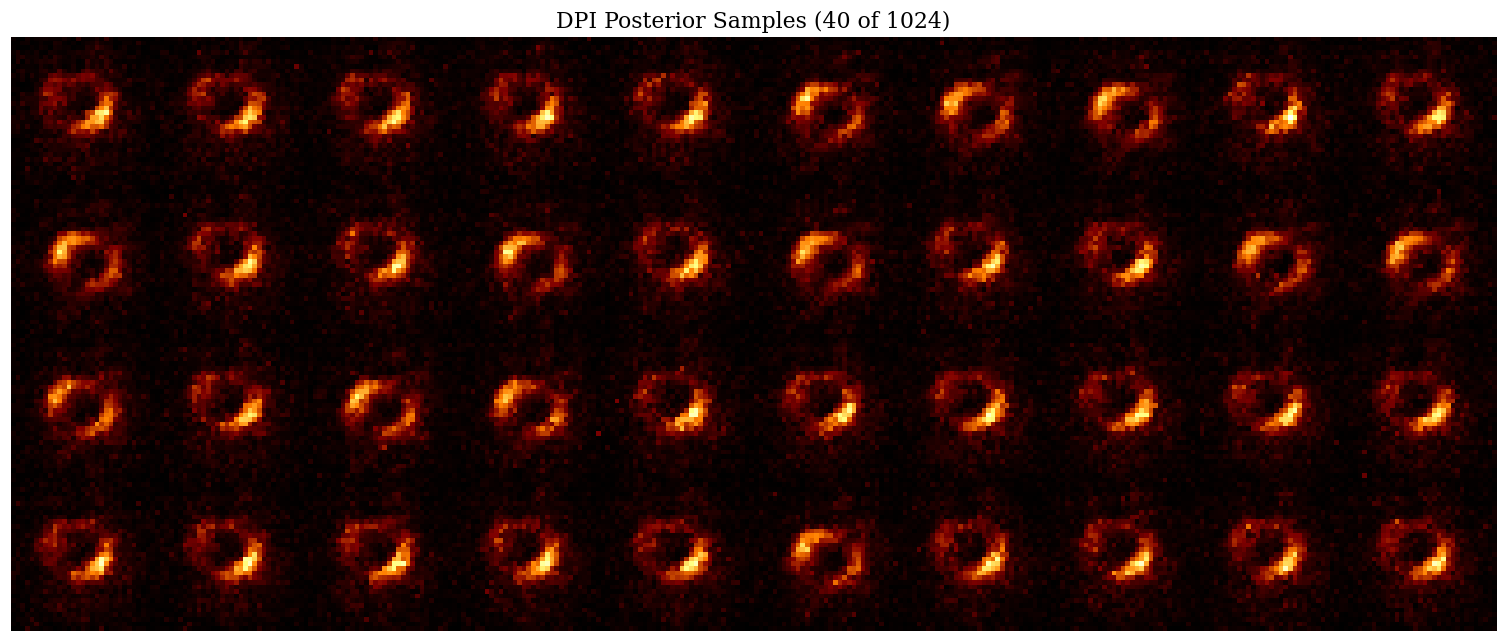

In [6]:
# Display a 4x10 grid of posterior samples (matching reference notebook)
image_stitch = np.zeros((npix * 4, npix * 10))
for k in range(40):
    i = k // 10
    j = k % 10
    image_stitch[npix*i:npix*(i+1), npix*j:npix*(j+1)] = samples[k]

plt.figure(figsize=(15, 6))
plt.imshow(image_stitch, origin='lower', cmap='afmhot')
plt.title('DPI Posterior Samples (40 of 1024)')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 4. Posterior Mean & Uncertainty Maps

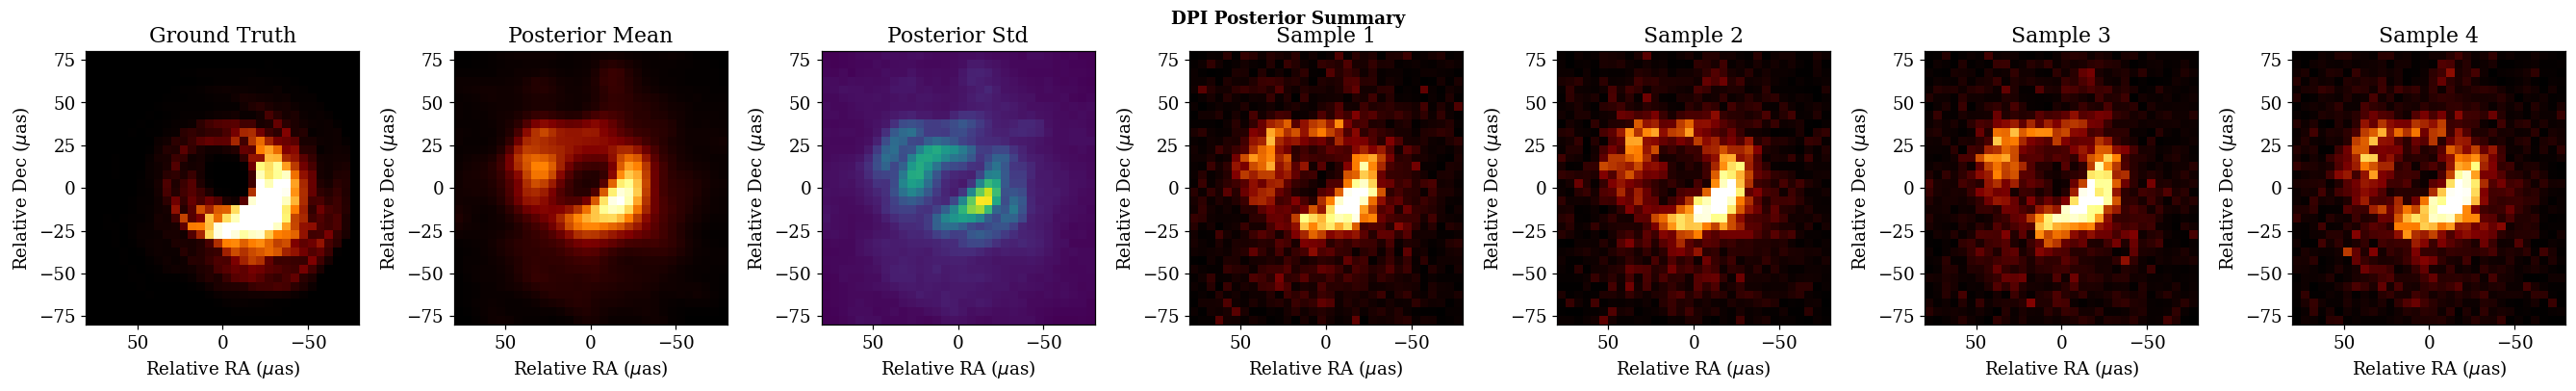

In [7]:
plot_posterior_summary(
    posterior_mean, posterior_std, samples,
    ground_truth=ground_truth,
    pixel_size_uas=pixel_size_uas,
)
plt.suptitle('DPI Posterior Summary', y=1.02, fontsize=12, fontweight='bold')
plt.show()

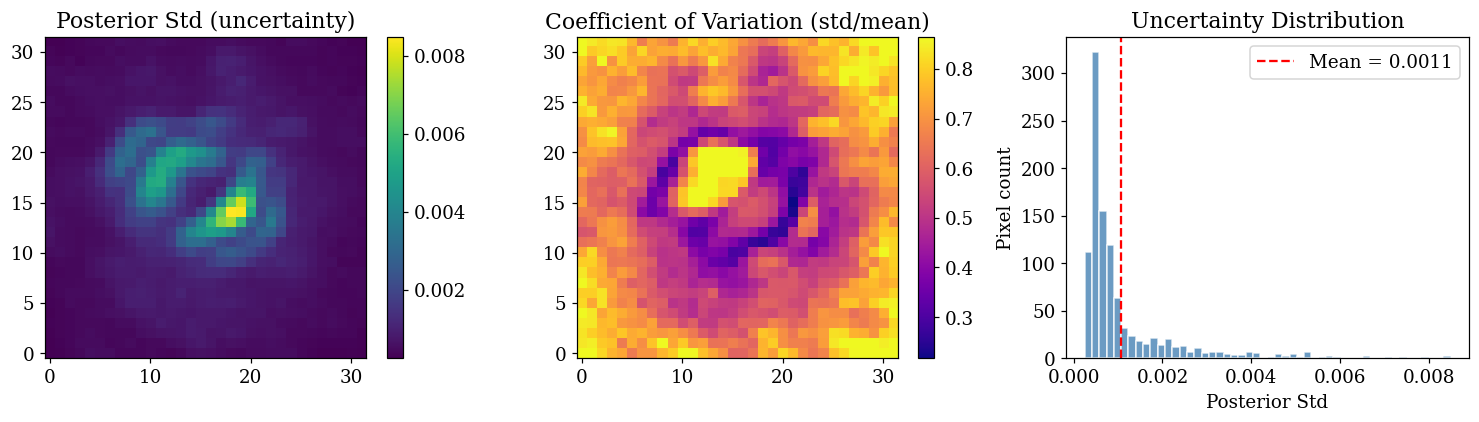

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(posterior_std, origin='lower', cmap='viridis')
axes[0].set_title('Posterior Std (uncertainty)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

cv = posterior_std / (posterior_mean + 1e-10)
im1 = axes[1].imshow(cv, origin='lower', cmap='plasma',
                      vmax=np.percentile(cv, 95))
axes[1].set_title('Coefficient of Variation (std/mean)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].hist(posterior_std.flatten(), bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Posterior Std')
axes[2].set_ylabel('Pixel count')
axes[2].set_title('Uncertainty Distribution')
axes[2].axvline(posterior_std.mean(), color='red', ls='--',
                label=f'Mean = {posterior_std.mean():.4f}')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 5. Multi-Modal Posterior (t-SNE + K-Means)

The DPI posterior for EHT data is known to be **multi-modal**: the sparse
uv-coverage admits multiple plausible ring orientations. We use t-SNE to
visualize the sample distribution in 2D, then K-Means to identify distinct
modes and compute per-mode statistics.

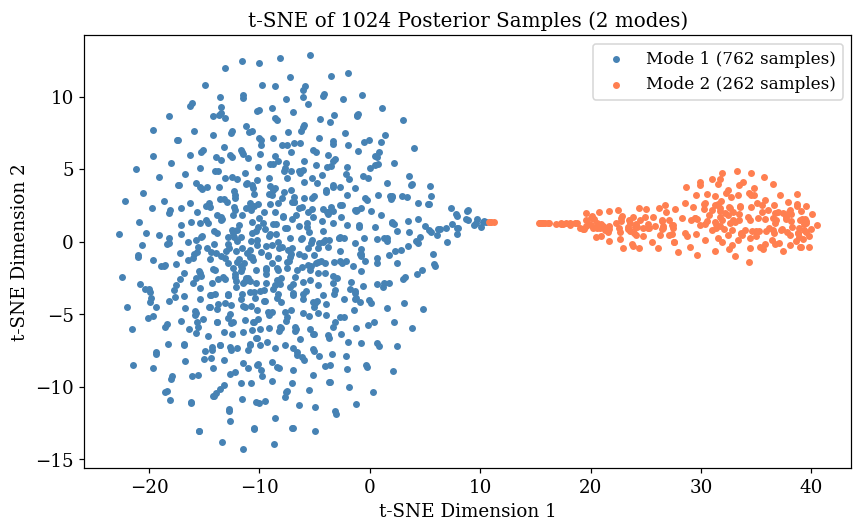

Mode 1: 762 samples
Mode 2: 262 samples
Silhouette score: 0.7105 (>0.2 indicates meaningful separation)


In [9]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = samples.reshape(-1, npix * npix)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X_embedded)

plt.figure(figsize=(8, 5))
for label, color in [(0, 'steelblue'), (1, 'coral')]:
    mask = kmeans.labels_ == label
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1],
                c=color, marker='.', s=50,
                label=f'Mode {label+1} ({mask.sum()} samples)')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('t-SNE of 1024 Posterior Samples (2 modes)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

sil = silhouette_score(X_embedded, kmeans.labels_)
print(f'Mode 1: {(kmeans.labels_==0).sum()} samples')
print(f'Mode 2: {(kmeans.labels_==1).sum()} samples')
print(f'Silhouette score: {sil:.4f} (>0.2 indicates meaningful separation)')

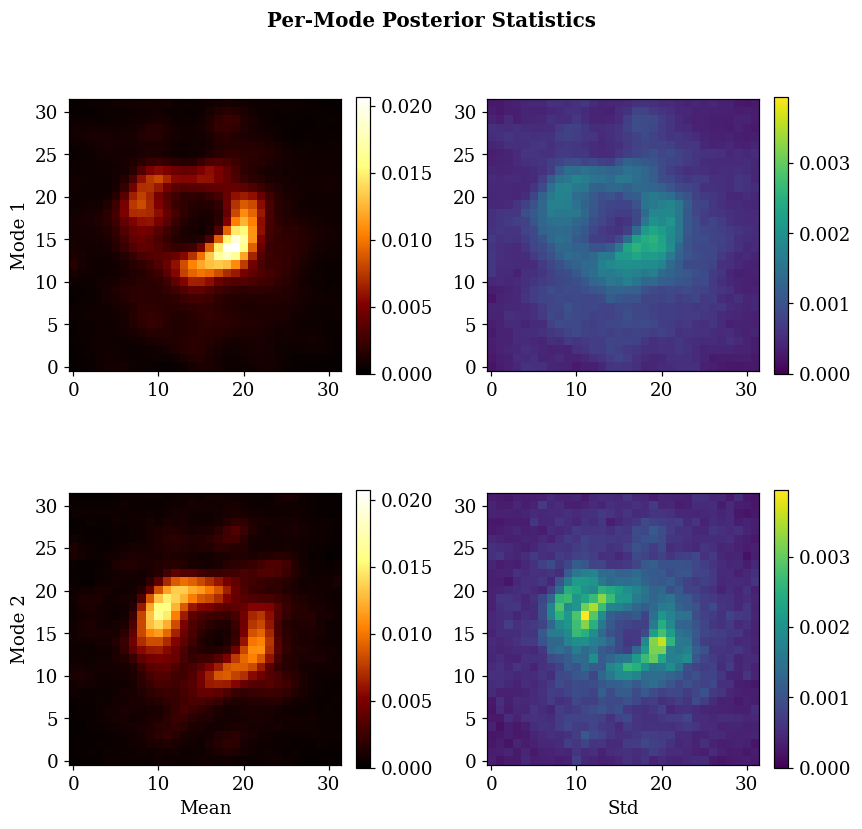

In [10]:
# Per-mode mean and std (matching reference notebook Figure 7)
img_mean1 = np.mean(samples[kmeans.labels_ == 0], axis=0)
img_std1 = np.std(samples[kmeans.labels_ == 0], axis=0)
img_mean2 = np.mean(samples[kmeans.labels_ == 1], axis=0)
img_std2 = np.std(samples[kmeans.labels_ == 1], axis=0)

vmax_mean = max(img_mean1.max(), img_mean2.max())
vmax_std = max(img_std1.max(), img_std2.max())

fig, axs = plt.subplots(2, 2, figsize=(8, 8))

im = axs[0, 0].imshow(img_mean1, origin='lower', cmap='afmhot',
                        vmin=0, vmax=vmax_mean)
axs[0, 0].set_ylabel('Mode 1')
fig.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(img_std1, origin='lower', cmap='viridis',
                        vmin=0, vmax=vmax_std)
fig.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[1, 0].imshow(img_mean2, origin='lower', cmap='afmhot',
                        vmin=0, vmax=vmax_mean)
axs[1, 0].set_ylabel('Mode 2')
axs[1, 0].set_xlabel('Mean')
fig.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(img_std2, origin='lower', cmap='viridis',
                        vmin=0, vmax=vmax_std)
axs[1, 1].set_xlabel('Std')
fig.colorbar(im, ax=axs[1, 1], fraction=0.046)

plt.suptitle('Per-Mode Posterior Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Per-mode reconstruction quality vs ground truth
metrics_mode1 = compute_metrics(img_mean1, ground_truth)
metrics_mode2 = compute_metrics(img_mean2, ground_truth)
metrics_all = compute_metrics(posterior_mean, ground_truth)

print(f'{"Metric":<12} {"All samples":>12} {"Mode 1":>12} {"Mode 2":>12}')
print('-' * 50)
for key in ['nrmse', 'ncc']:
    print(f'{key.upper():<12} {metrics_all[key]:>12.4f} {metrics_mode1[key]:>12.4f} {metrics_mode2[key]:>12.4f}')

# Identify which mode is closer to ground truth
better = 1 if metrics_mode1['nrmse'] < metrics_mode2['nrmse'] else 2
print(f'\nMode {better} is closer to the ground truth (lower NRMSE).')

Metric        All samples       Mode 1       Mode 2
--------------------------------------------------
NRMSE              0.1338       0.1188       0.1616
NCC                0.6552       0.6055       0.4909

Mode 1 is closer to the ground truth (lower NRMSE).


---
## 6. Forward Model Verification

Verify that the posterior mean produces closure quantities consistent with
the observed data.

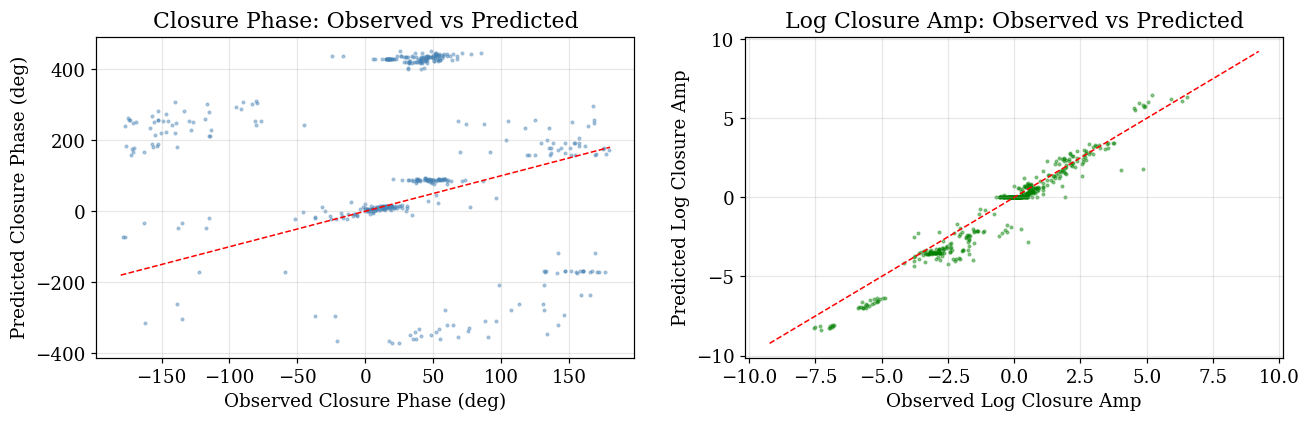

Closure phase RMSE : 272.99 deg
Log closure amp RMSE: 0.6707


In [12]:
# Build forward model
cphase_ind_torch = [torch.tensor(a, dtype=torch.long)
                    for a in closure_indices['cphase_ind_list']]
cphase_sign_torch = [torch.tensor(a, dtype=torch.float32)
                     for a in closure_indices['cphase_sign_list']]
camp_ind_torch = [torch.tensor(a, dtype=torch.long)
                  for a in closure_indices['camp_ind_list']]

forward_model = NUFFTForwardModel(
    npix, nufft_params['ktraj_vis'], nufft_params['pulsefac_vis'],
    cphase_ind_torch, cphase_sign_torch, camp_ind_torch,
    device=torch.device('cpu'),
)

# Forward pass on posterior mean
mean_tensor = torch.tensor(posterior_mean, dtype=torch.float32).unsqueeze(0)
vis, visamp, cphase, logcamp = forward_model(mean_tensor)

# Observed data
cphase_obs = np.array(closure_indices['cphase_data']['cphase'])
logcamp_obs = np.array(closure_indices['logcamp_data']['camp'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(cphase_obs, cphase[0].detach().numpy(),
                s=3, alpha=0.4, c='steelblue')
axes[0].plot([-180, 180], [-180, 180], 'r--', lw=1)
axes[0].set_xlabel('Observed Closure Phase (deg)')
axes[0].set_ylabel('Predicted Closure Phase (deg)')
axes[0].set_title('Closure Phase: Observed vs Predicted')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(logcamp_obs, logcamp[0].detach().numpy(),
                s=3, alpha=0.4, c='green')
lim = max(abs(logcamp_obs).max(), abs(logcamp[0].detach().numpy()).max()) * 1.1
axes[1].plot([-lim, lim], [-lim, lim], 'r--', lw=1)
axes[1].set_xlabel('Observed Log Closure Amp')
axes[1].set_ylabel('Predicted Log Closure Amp')
axes[1].set_title('Log Closure Amp: Observed vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cp_rmse = np.sqrt(np.mean((cphase_obs - cphase[0].detach().numpy())**2))
lca_rmse = np.sqrt(np.mean((logcamp_obs - logcamp[0].detach().numpy())**2))
print(f'Closure phase RMSE : {cp_rmse:.2f} deg')
print(f'Log closure amp RMSE: {lca_rmse:.4f}')

---
## 7. Training from Scratch (Optional)

To train DPI from scratch instead of using the pretrained checkpoint,
uncomment and run the cell below. Training for 10,000 epochs is sufficient
and takes ~10-20 minutes on GPU.

In [13]:
# # Uncomment to train from scratch:
# TRAIN_FROM_SCRATCH = False
#
# if TRAIN_FROM_SCRATCH:
#     solver = DPISolver(
#         npix=npix, n_flow=16,
#         n_epoch=10000,
#         batch_size=32, lr=1e-4,
#         logdet_weight=1.0, l1_weight=1.0, tsv_weight=100.0,
#         flux_weight=1000.0, center_weight=1.0, mem_weight=1024.0,
#         grad_clip=0.1,
#         data_warmup=True,          # data weight warm-up
#         warmup_starting_order=4,   # start at 10^{-4}
#         warmup_decay_rate=2000,    # +1 order per 2000 epochs
#         device=device,
#     )
#     result = solver.reconstruct(
#         obs_data, closure_indices, nufft_params,
#         prior_image, flux_const)
#     plot_loss_curves(result['loss_history'])
#     plt.show()
#
#     # Use trained model for sampling
#     img_generator = result['img_generator']
#     logscale_factor = result['logscale_factor']

### Loss Curves (from reference training)

The loss history from the pretrained model's 10,000-epoch training with data weight warm-up.
Note how the closure phase and log closure amplitude losses decrease smoothly
as the data weight ramps up from 10⁻⁴ to 1.0:

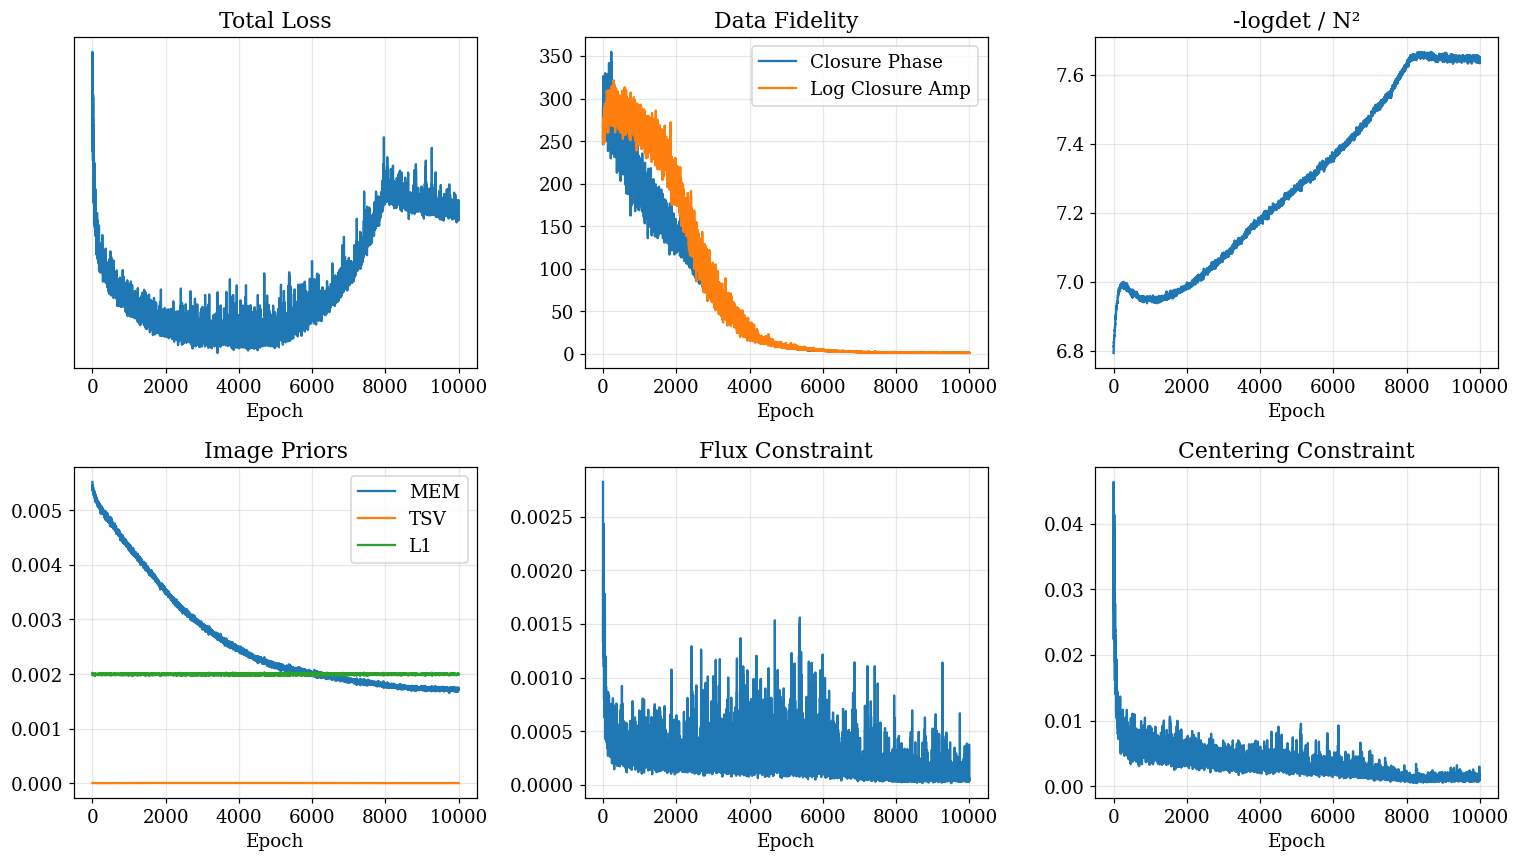

Total epochs: 10000
Final total loss: 38.4765


In [14]:
loss_path = os.path.join(REF_DIR, 'loss_history.npy')
if os.path.exists(loss_path):
    loss_history = np.load(loss_path, allow_pickle=True).item()
    plot_loss_curves(loss_history)
    plt.show()

    print(f'Total epochs: {len(loss_history["total"])}')
    print(f'Final total loss: {np.mean(loss_history["total"][-100:]):.4f}')
else:
    print('Loss history not available (run training first).')

---
## 8. Evaluation & Metrics

In [15]:
metrics = compute_metrics(posterior_mean, ground_truth)
uq_metrics = compute_uq_metrics(posterior_mean, posterior_std, ground_truth)

print('Reconstruction quality:')
print_metrics_table(metrics)
print()
print('Uncertainty quantification:')
print_metrics_table(uq_metrics)
print()
print('Metric definitions:')
print('  NRMSE       : normalised RMSE (lower is better)')
print('  NCC         : normalised cross-correlation (higher is better, max 1)')
print('  Calibration : fraction of GT pixels within 1-sigma (ideal ~ 0.68)')
print('  Mean uncert : average posterior std (lower = more confident)')

Reconstruction quality:
  Metric                    Value
  --------------------------------
  nrmse                    0.1338
  ncc                      0.6552
  dynamic_range           13.7351

Uncertainty quantification:
  Metric                    Value
  --------------------------------
  nrmse                    0.1338
  ncc                      0.6552
  dynamic_range           13.7351
  calibration              0.1787
  mean_uncertainty         0.0011

Metric definitions:
  NRMSE       : normalised RMSE (lower is better)
  NCC         : normalised cross-correlation (higher is better, max 1)
  Calibration : fraction of GT pixels within 1-sigma (ideal ~ 0.68)
  Mean uncert : average posterior std (lower = more confident)


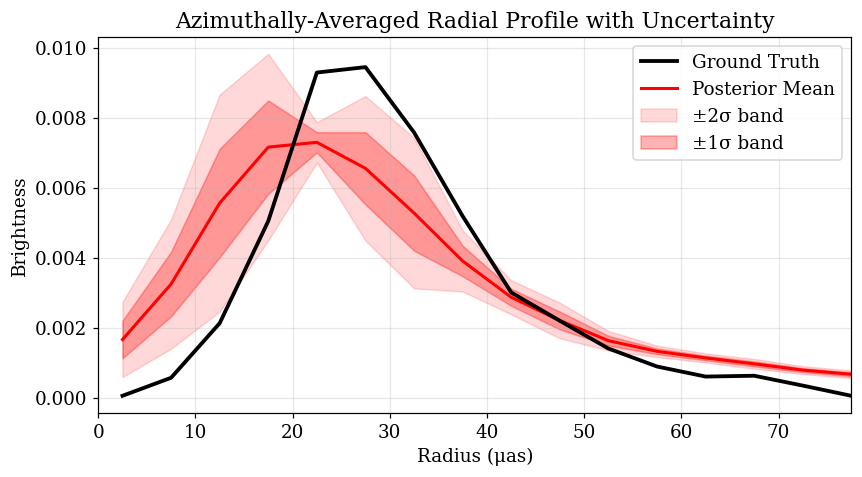

In [16]:
# Azimuthally-averaged radial profiles with uncertainty bands
center = npix // 2
y_grid, x_grid = np.mgrid[0:npix, 0:npix]
r_grid = np.sqrt((x_grid - center + 0.5)**2 + (y_grid - center + 0.5)**2)
r_bins = np.arange(0, npix // 2 + 1)

def radial_profile(image, r_grid, r_bins):
    profile = np.zeros(len(r_bins) - 1)
    for i in range(len(r_bins) - 1):
        mask = (r_grid >= r_bins[i]) & (r_grid < r_bins[i+1])
        if mask.sum() > 0:
            profile[i] = image[mask].mean()
    return profile

n_prof = min(200, samples.shape[0])
profiles = np.array([radial_profile(samples[i], r_grid, r_bins)
                     for i in range(n_prof)])
r_uas = (r_bins[:-1] + 0.5) * pixel_size_uas

gt_profile = radial_profile(ground_truth, r_grid, r_bins)
mean_profile = np.mean(profiles, axis=0)
std_profile = np.std(profiles, axis=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(r_uas, gt_profile, 'k-', lw=2.5, label='Ground Truth', zorder=5)
ax.plot(r_uas, mean_profile, 'r-', lw=2, label='Posterior Mean')
ax.fill_between(r_uas,
                mean_profile - 2*std_profile,
                mean_profile + 2*std_profile,
                alpha=0.15, color='red', label='\u00b12\u03c3 band')
ax.fill_between(r_uas,
                mean_profile - std_profile,
                mean_profile + std_profile,
                alpha=0.3, color='red', label='\u00b11\u03c3 band')
ax.set_xlabel('Radius (\u03bcas)')
ax.set_ylabel('Brightness')
ax.set_title('Azimuthally-Averaged Radial Profile with Uncertainty')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, r_uas[-1])
plt.tight_layout()
plt.show()

---
## Summary

| Aspect | Detail |
|--------|--------|
| **Method** | Deep Probabilistic Imaging (Real-NVP normalizing flow) |
| **Data** | Closure phases + log closure amplitudes (gain-invariant) |
| **Architecture** | 16 flow blocks, each with 2 affine coupling layers |
| **Training** | KL divergence: data fidelity + image priors - entropy |
| **Annealing** | Data weight warm-up: 10⁻⁴ → 1.0 over ~8000 epochs |
| **Output** | Full posterior: mean, std, 1024 samples |
| **Key result** | Multi-modal posterior (2 ring orientations via t-SNE) |
| **Advantage** | Instant posterior sampling, principled UQ |

**Reference:** Sun, H. & Bouman, K.L. (2020). *Deep Probabilistic Imaging*. arXiv:2010.14462